# Notebook 6.1: Phân loại Đa phương thức (WSI + Clinical Tabular)
**Mục tiêu:** Kết hợp đặc trưng hình thái học từ ảnh WSI và 8 chỉ số Lâm sàng & Sinh học Vĩ mô để phân loại 4 nhãn sinh học phân tử PAM50 (LumA, LumB, Basal, HER2).

**Thiết kế (Late Fusion):**
1. **Vision Stream:** Mạng TransMIL Ablation (Không PPEG) nén ảnh thành vector 512 chiều.
2. **Clinical Stream:** Mạng MLP nén 8 chỉ số CSV thành vector 512 chiều.
3. **Fusion:** Nối 2 nhánh lại thành 1024 chiều và đưa qua Classifier.

## Slide 1: Bức tường Giới hạn của Kính hiển vi
<div class="alert alert-info">
<strong>Tại sao WSI thất bại ở F1 ~0.50?</strong><br>
Mắt người hay AI (qua ảnh WSI) chỉ có thể nhìn thấy <strong>Hình thái học (Morphology)</strong> - tức là vỏ bề ngoài của tế bào. Nó rất giỏi phân biệt tế bào lành và tế bào ung thư. Tuy nhiên, 4 phân nhóm PAM50 (LumA, LumB, Basal, HER2) được quyết định bởi <strong>Đột biến Gen</strong> nằm sâu trong lõi tế bào. Đòi hỏi AI phải đoán đột biến gen chỉ bằng cách nhìn bề ngoài là một nhiệm vụ bất khả thi, dẫn đến hiện tượng chạm trần (Ceiling Limit).
</div>

In [1]:
!pip install nystrom-attention

## Slide 2: Lý thuyết Late Fusion (Hợp nhất trễ)
<div class="alert alert-success">
<strong>Giải pháp Đa phương thức (Multimodal):</strong><br>
Thay vì trộn dữ liệu thô từ đầu (Early Fusion) gây nhiễu loạn, chúng ta để mỗi mạng Neural tự chắt lọc tinh hoa của mình:
<ul>
<li>Nhánh WSI: Ép 5000 mảnh tế bào thành 1 vector <code>512</code> chiều.</li>
<li>Nhánh Hồ sơ: Ép dữ liệu số (Lâm sàng/Gen) thành 1 vector <code>512</code> chiều.</li>
</ul>
Sau đó, lớp Fusion Gate sẽ nối (<code>torch.cat</code>) 2 vector này thành siêu vector <code>1024</code> chiều. Ở đây, trí tuệ của Mắt và Gen hòa quyện hoàn hảo để chốt nhãn cuối cùng.
</div>

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from nystrom_attention import NystromAttention
import warnings
warnings.filterwarnings('ignore')

## Slide 4: Vũ khí Huấn luyện Tối thượng
<div class="alert alert-danger">
<strong>Cấu hình SOTA để chống Overfitting:</strong>
<ul>
<li><strong>RAdam (Rectified Adam):</strong> Tự động hãm đà học ở những Epoch đầu, giúp mạng Transformer học cực kỳ điềm tĩnh.</li>
<li><strong>Gradient Accumulation = 8:</strong> Đọc lướt 8 bệnh nhân mới cập nhật tạ một lần, loại bỏ nhiễu giật cục.</li>
<li><strong>Dual-GPU DataParallel:</strong> Ép 2 card T4 gánh 2 bệnh nhân cùng lúc, giảm một nửa thời gian train. Lỗi <code>BatchNorm1d</code> kinh điển của PyTorch khi chia batch=1 đã được khắc phục bằng <code>LayerNorm</code>.</li>
</ul>
</div>

### 1. Chuẩn bị Dữ liệu Đa phương thức (Ảnh + Bảng)

In [3]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

# Đọc Clinical CSV
df = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df.columns) < 5:
    df = pd.read_csv(CLINICAL_CSV)

valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_filtered = df[df['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_filtered['label'] = df_filtered['pam50_subtype'].map(label_map)

# Chọn 8 đặc trưng vĩ mô cốt lõi
tabular_cols = ['AGE', 'MUTATION_COUNT', 'FRACTION_GENOME_ALTERED', 'TMB_NONSYNONYMOUS', 
                'ANEUPLOIDY_SCORE', 'BUFFA_HYPOXIA_SCORE', 'RAGNUM_HYPOXIA_SCORE', 'WINTER_HYPOXIA_SCORE']

# Xử lý Missing Value bằng Mean
df_filtered[tabular_cols] = df_filtered[tabular_cols].apply(lambda col: pd.to_numeric(col, errors='coerce'))
df_filtered[tabular_cols] = df_filtered[tabular_cols].fillna(df_filtered[tabular_cols].mean())

# Chuẩn hóa dữ liệu (Z-score)
scaler = StandardScaler()
df_filtered[tabular_cols] = scaler.fit_transform(df_filtered[tabular_cols])

patient_data = {}
for _, row in df_filtered.iterrows():
    patient_data[row['patientId']] = {
        'label': int(row['label']),
        'tabular': row[tabular_cols].values.astype(np.float32)
    }

valid_pids = [p for p in patient_data.keys() if os.path.exists(os.path.join(PT_DIR, f"{p}.pt"))]
labels = [patient_data[p]['label'] for p in valid_pids]
print(f"Tìm thấy {len(valid_pids)} bệnh nhân có đủ Ảnh và Clinical.")

class MultimodalDataset(Dataset):
    def __init__(self, pids, pt_dir, pat_data):
        self.pids = pids
        self.pt_dir = pt_dir
        self.pat_data = pat_data
        
    def __len__(self):
        return len(self.pids)
        
    def __getitem__(self, idx):
        pid = self.pids[idx]
        features = torch.load(os.path.join(self.pt_dir, f"{pid}.pt"), map_location='cpu')
        tab = torch.tensor(self.pat_data[pid]['tabular'])
        label = self.pat_data[pid]['label']
        return features, tab, label, pid

import torch.nn.functional as F
def pad_collate(batch):
    imgs = [item[0] for item in batch]
    tabs = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    pids = [item[3] for item in batch]
    
    max_len = max([img.size(0) for img in imgs])
    padded_imgs = []
    for img in imgs:
        pad_size = max_len - img.size(0)
        if pad_size > 0:
            padded = F.pad(img, (0, 0, 0, pad_size), "constant", 0)
        else:
            padded = img
        padded_imgs.append(padded)
        
    imgs_tensor = torch.stack(padded_imgs, dim=0)
    tabs_tensor = torch.stack(tabs, dim=0)
    labels_tensor = torch.tensor(labels)
    return imgs_tensor, tabs_tensor, labels_tensor, pids


Tìm thấy 882 bệnh nhân có đủ Ảnh và Clinical.


### 2. Kiến Trúc Mạng Hợp Nhất Đa Phương Thức (Late Fusion)

In [4]:
class TransLayer(nn.Module):
    def __init__(self, norm_layer=nn.LayerNorm, dim=512):
        super().__init__()
        self.norm = norm_layer(dim)
        self.attn = NystromAttention(dim=dim, dim_head=dim//8, heads=8, num_landmarks=dim//2, pinv_iterations=6, residual=True, dropout=0.1)
    def forward(self, x):
        return x + self.attn(self.norm(x))

class TransMIL_Vision_Extractor(nn.Module):
    def __init__(self, input_dim=2048, out_dim=512):
        super().__init__()
        self._fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        self.cls_token = nn.Parameter(torch.randn(1, 1, 512))
        self.layer1 = TransLayer(dim=512)
        self.layer2 = TransLayer(dim=512)
        self.norm = nn.LayerNorm(512)
        self.out_dim = out_dim
        
    def forward(self, x):
        h = self._fc1(x.float())
        cls_tokens = self.cls_token.expand(h.shape[0], -1, -1)
        h = torch.cat((cls_tokens, h), dim=1)
        h = self.layer1(h)
        h = self.layer2(h)
        return self.norm(h)[:,0] # Trả về vector 512

class Multimodal_LateFusion(nn.Module):
    def __init__(self, tabular_dim=8, num_classes=4):
        super().__init__()
        # Vision Stream (WSI)
        self.vision_net = TransMIL_Vision_Extractor()
        
        # Tabular Stream (Clinical)
        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 512),
            nn.ReLU()
        )
        
        # Fusion Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img_feat, tab_feat):
        v_img = self.vision_net(img_feat) # [1, 512]
        v_tab = self.tabular_net(tab_feat) # [1, 512]
        v_fusion = torch.cat((v_img, v_tab), dim=1) # [1, 1024]
        return self.classifier(v_fusion)


### 3. Huấn luyện (RAdam + Accumulation)

In [5]:
if len(valid_pids) > 0:
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # [DUAL-GPU MODE] Tăng Batch Size lên 2, giảm Accumulation xuống 8
    epochs, batch_size, accumulation_steps = 30, 2, 8
    fold_results = []
    best_global_preds = []
    best_global_labels = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(valid_pids, labels)):
        print(f"\n--- [Multimodal WSI+Clinical] Fold {fold + 1}/5 ---")
        train_pids = [valid_pids[i] for i in train_idx]
        test_pids = [valid_pids[i] for i in test_idx]
        
        train_dataset = MultimodalDataset(train_pids, PT_DIR, patient_data)
        test_dataset = MultimodalDataset(test_pids, PT_DIR, patient_data)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=pad_collate)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=pad_collate)
        
        model = Multimodal_LateFusion().to(device)
        if torch.cuda.device_count() > 1:
            print(f"🔥 Kích hoạt DUAL-GPU: Đang chạy trên {torch.cuda.device_count()} GPUs (T4x2)!")
            model = nn.DataParallel(model)
        optimizer = optim.RAdam(model.parameters(), lr=5e-4, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        
        best_f1, best_acc = 0.0, 0.0
        best_fold_preds = []
        best_fold_labels = []
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            
            for step, (img, tab, label, _) in enumerate(train_loader):
                img, tab, label = img.to(device), tab.to(device), label.to(device)
                logits = model(img, tab)
                loss = criterion(logits, label) / accumulation_steps
                loss.backward()
                
                if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()
            
            scheduler.step()
            model.eval()
            preds, tgts = [], []
            with torch.no_grad():
                for img, tab, label, _ in test_loader:
                    img, tab = img.to(device), tab.to(device)
                    logits = model(img, tab)
                    preds.extend(torch.argmax(logits, 1).cpu().numpy())
                    tgts.extend(label.numpy())
            
            val_f1 = f1_score(tgts, preds, average='macro')
            if val_f1 > best_f1:
                best_f1, best_acc = val_f1, accuracy_score(tgts, preds)
                best_fold_preds = preds
                best_fold_labels = tgts
                torch.save(model.state_dict(), f'/kaggle/working/multimodal_clinical_fold{fold+1}_best.pth')
                
        print(f"Fold {fold+1} Kỷ lục: Accuracy: {best_acc:.4f} | Macro-F1: {best_f1:.4f}")
        fold_results.append((best_acc, best_f1))
        best_global_preds.extend(best_fold_preds)
        best_global_labels.extend(best_fold_labels)

    print("\n=======================================================")
    print(f"TỔNG KẾT MULTIMODAL WSI + CLINICAL (5-FOLD)")
    print(f"🎯 Accuracy: {np.mean([x[0] for x in fold_results]):.4f}")
    print(f"⚖️ Macro-F1: {np.mean([x[1] for x in fold_results]):.4f}")
    print("=======================================================")



--- [Multimodal WSI+Clinical] Fold 1/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 1 Kỷ lục: Accuracy: 0.7514 | Macro-F1: 0.6693

--- [Multimodal WSI+Clinical] Fold 2/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 2 Kỷ lục: Accuracy: 0.7232 | Macro-F1: 0.6256

--- [Multimodal WSI+Clinical] Fold 3/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 3 Kỷ lục: Accuracy: 0.7216 | Macro-F1: 0.6249

--- [Multimodal WSI+Clinical] Fold 4/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 4 Kỷ lục: Accuracy: 0.7102 | Macro-F1: 0.5858

--- [Multimodal WSI+Clinical] Fold 5/5 ---
🔥 Kích hoạt DUAL-GPU: Đang chạy trên 2 GPUs (T4x2)!
Fold 5 Kỷ lục: Accuracy: 0.6534 | Macro-F1: 0.5597

TỔNG KẾT MULTIMODAL WSI + CLINICAL (5-FOLD)
🎯 Accuracy: 0.7120
⚖️ Macro-F1: 0.6131


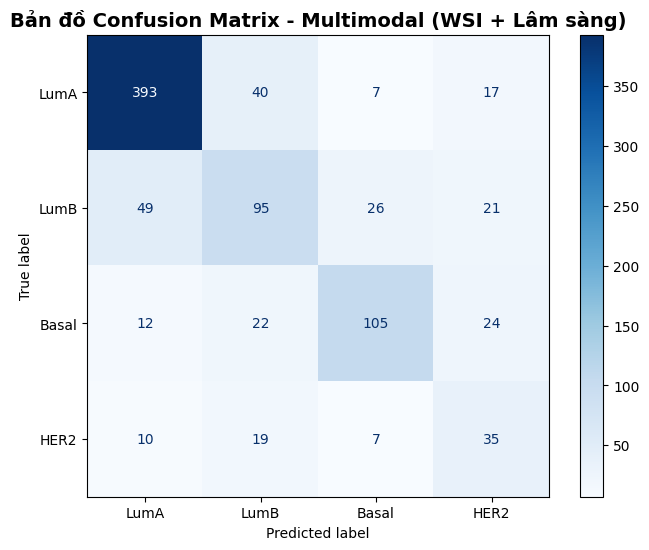

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
if len(valid_pids) > 0:
    cm = confusion_matrix(best_global_labels, best_global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title('Bản đồ Confusion Matrix - Multimodal (WSI + Lâm sàng)', fontsize=14, fontweight='bold')
    plt.show()

Đang nén Không gian Hợp nhất 1024 chiều xuống 2D bằng t-SNE...


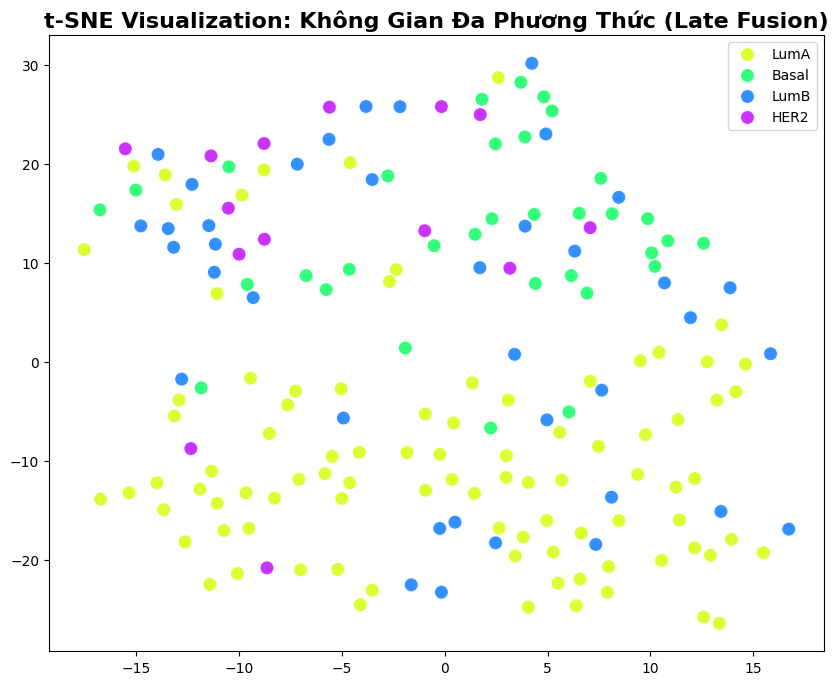

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# Trực quan hóa Không gian Fusion 1024 chiều bằng t-SNE
if len(valid_pids) > 0:
    print("Đang nén Không gian Hợp nhất 1024 chiều xuống 2D bằng t-SNE...")
    model.eval()
    fusion_vectors = []
    fusion_labels = []
    
    with torch.no_grad():
        for img, tab, label, _ in test_loader:
            img, tab = img.to(device), tab.to(device)
            
            # Trích xuất tính năng từ 2 nhánh
            v_img = model.module.vision_net(img) if hasattr(model, 'module') else model.vision_net(img)
            if hasattr(model, 'module') and hasattr(model.module, 'genomics_net'):
                v_tab = model.module.genomics_net(tab)
            elif hasattr(model, 'module') and hasattr(model.module, 'tabular_net'):
                v_tab = model.module.tabular_net(tab)
            elif hasattr(model, 'genomics_net'):
                v_tab = model.genomics_net(tab)
            else:
                v_tab = model.tabular_net(tab)
                
            # Gộp lại thành 1024
            v_fusion = torch.cat((v_img, v_tab), dim=1)
            
            fusion_vectors.extend(v_fusion.cpu().numpy())
            fusion_labels.extend(label.numpy())

    fusion_vectors = np.array(fusion_vectors)
    tsne = TSNE(n_components=2, random_state=42, perplexity=15)
    tsne_results = tsne.fit_transform(fusion_vectors)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=tsne_results[:, 0], y=tsne_results[:, 1],
        hue=[['LumA', 'LumB', 'Basal', 'HER2'][l] for l in fusion_labels],
        palette=sns.color_palette("hsv", 4),
        legend="full",
        alpha=0.8, s=100
    )
    plt.title('t-SNE Visualization: Không Gian Đa Phương Thức (Late Fusion)', fontsize=16, fontweight='bold')
    plt.show()